Name: Dano Alvin John S.


Instructions:

    Create a Python notebook to answer all shown procedures, exercises and analysis in this section.

Resources:

    Download the following datasets: earthquakes-1.csv Download earthquakes-1.csv, fb_stock_prices_2018.csv Download fb_stock_prices_2018.csv

Procedures:

    9.1 Introduction to Matplotlib
    9.2 Plotting with Pandas
    9.3 Pandas Plotting Subpackage

Data Analysis:

    Provide comments on output from the procedures above.

Supplementary Activity:

Using the CSV files provided and what we have learned so far in this module complete the following exercises:

    Plot the rolling 20-day minimum of the Facebook closing price with the pandas plot() method.

    Create a histogram and KDE of the change from open to close in the price of Facebook stock.

    Using the earthquake data, create box plots for the magnitudes of each magType used in Indonesia.

    Make a line plot of the difference between the weekly maximum high price and the weekly minimum low price for Facebook. This should be a single
    line.

    Using matplotlib and pandas, create two subplots side-by-side showing the effect that after-hours trading has had on Facebook's stock price:

        The first subplot will contain a line plot of the daily difference between that day's opening price and the prior day's closing price (be sure to review the Time series section of Aggregating Pandas DataFrames for an easy way to do this).

        The second subplot will be a bar plot showing the net effect this had monthly, using resample().

        Bonus #1: Color the bars according to whether they are gains in the stock price (green) or drops in the stock price (red).

        Bonus #2: Modify the x-axis of the bar plot to show the threeletter abbreviation for the month.


    9.1 Introduction to Matplotlib
Analyzing this notebook, it came to my attention that Matplotlib and Pandas to visualize Facebook stock prices and earthquake data, creating line plots, scatter plots, and histograms to analyze trends and distributions. Showcasing the work of subplots, gridspec layouts, and saving/closing figures, while exploring rcParams to customize and reset figure settings. This gave them practical experience in plotting, layout management, and data presentation.

    9.2 Plotting with Pandas
Basically it showed the ability of Pandas plotting. It showed Facebook stock and earthquake data to see how different charts tell different stories. I came on a realization that line plots are great for watching stocks move over time, while scatter plots let you explore how variables relate to each other (you can even play with log scales and transparency for trickier data). When things get crowded, hexbin plots show density nicely. Heatmaps are perfect for correlations, and histograms with KDE let you see distributions with overlays. ECDF plots are a cool way to see cumulative probabilities, super useful for earthquake magnitudes. Boxplots handle outliers and grouped data well, and bar charts (stacked, normalized, you name it) summarize counts any way you need. The best part is how easy Pandas makes it to tweak titles, legends, and transparency so your charts actually make sense.

    9.3 Pandas Plotting Subpackage
  This notebook after reading was demonstrates an analysis of Facebook’s stock price data for 2018 in which by imported the dataset using pandas and set the date column as a datetime index to facilitate time series visualization. A scatter matrix was used to explore the relationships between numerical columns, and by changing the diagonal from histograms to kernel density estimates "KDE" they say with this it was much easier and has a smoother distributions and better understand patterns in the data. Lag plots were applied to examine autocorrelation, revealing that while random data showed no discernible pattern the stock prices displayed significant correlation with their past values, indicating predictable trends over short time periods. Autocorrelation plots basically quantified relationship, confirming that the stock price series exhibits meaningful correlation across different lags, unlike random series. Finally, bootstrap plots were employed to assess uncertainty in summary statistics such as trading volume, allowing the analyst to visualize the variability and reliability of the data through repeated resampling.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as pl
import seaborn as sns
plt.style.use("seaborn-v0_8")
eq = pd.read_csv("earthquakes-1.csv")
fb = pd.read_csv("fb_stock_prices_2018.csv", parse_dates=["date"])
fb = fb.set_index("date").sort_index()
eq.head(), fb.head()


(    mag magType           time                  place  tsunami parsed_place
 0  1.35      ml  1539475168010  9km NE of Aguanga, CA        0   California
 1  1.29      ml  1539475129610  9km NE of Aguanga, CA        0   California
 2  3.42      ml  1539475062610  8km NE of Aguanga, CA        0   California
 3  0.44      ml  1539474978070  9km NE of Aguanga, CA        0   California
 4  2.16      md  1539474716050  10km NW of Avenal, CA        0   California,
               open    high       low   close    volume
 date                                                  
 2018-01-02  177.68  181.58  177.5500  181.42  18151903
 2018-01-03  181.88  184.78  181.3300  184.67  16886563
 2018-01-04  184.90  186.21  184.0996  184.33  13880896
 2018-01-05  185.59  186.90  184.9300  186.85  13574535
 2018-01-08  187.20  188.90  186.3300  188.28  17994726)

# Rolling 20-day minimum of the Facebook closing price

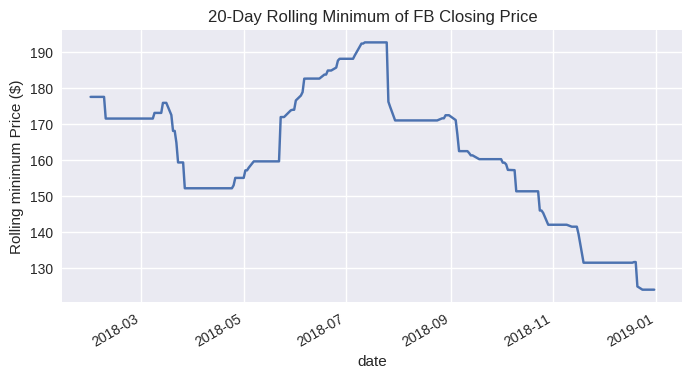

In [2]:
fb["close"].rolling(20).min().plot(figsize=(8,4), title="20-Day Rolling Minimum of FB Closing Price")
plt.ylabel("Rolling minimum Price ($)")
plt.show()


# Histogram + KDE of the change from open tos close

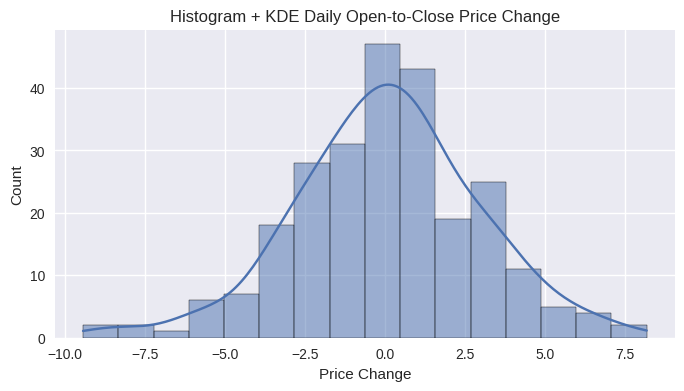

In [4]:
fb["change_open_close"] = fb["close"] - fb["open"]
plt.figure(figsize=(8,4))
sns.histplot(fb["change_open_close"], kde=True)
plt.title("Histogram + KDE Daily Open-to-Close Price Change")
plt.xlabel("Price Change")
plt.show()

# Box plots for magnitudes by magType (Indonesia only)

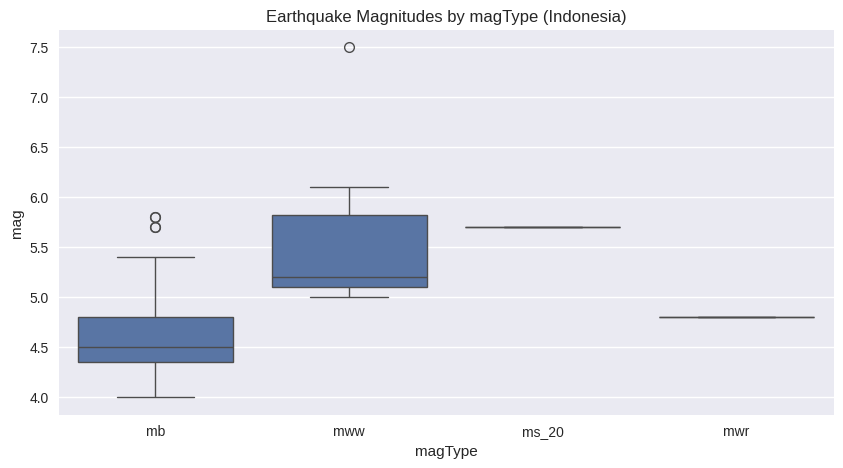

In [10]:
eq_id = eq[eq["parsed_place"] == "Indonesia"]
plt.figure(figsize=(10,5))
sns.boxplot(data=eq_id, x="magType", y="mag")
plt.title("Earthquake Magnitudes by magType (Indonesia)")
plt.show()

# Line plot: weekly max(high) − weekly min(low)

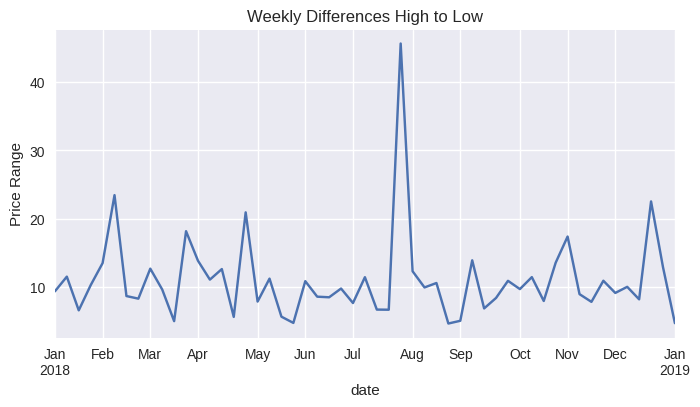

In [12]:
weekly_diff = fb.resample("W").agg({"high":"max","low":"min"})
weekly_diff["range"] = weekly_diff["high"] - weekly_diff["low"]
weekly_diff["range"].plot(figsize=(8,4), title="Weekly Differences High to Low")
plt.ylabel("Price Range")
plt.show()

# After-hours trading impact (two subplots) Compute required series

In [19]:
fb["prior_close"] = fb["close"].shift(1)
fb["after_hours_diff"] = fb["open"] - fb["prior_close"]
monthly_effect = fb["after_hours_diff"].resample("ME").sum()


# Daily difference: today's open − yesterday's

/tmp/ipykernel_396/3535270403.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_effect = fb["after_hours_diff"].resample("M").sum()


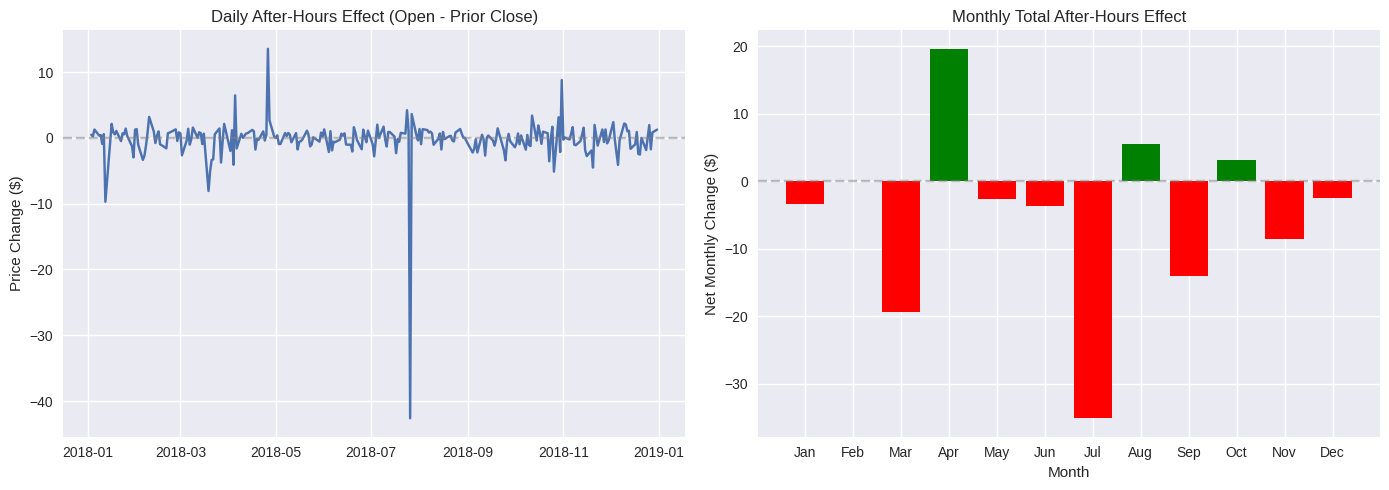

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fb.index, fb["after_hours_diff"])
axes[0].set_title("Daily After-Hours Effect (Open - Prior Close)")
axes[0].set_ylabel("Price Change ($)")
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.5)

monthly_effect = fb["after_hours_diff"].resample("M").sum()
colors = ["green" if v > 0 else "red" for v in monthly_effect]
axes[1].bar(monthly_effect.index.strftime("%b"), monthly_effect, color=colors)
axes[1].set_title("Monthly Total After-Hours Effect")
axes[1].set_ylabel("Net Monthly Change ($)")
axes[1].set_xlabel("Month")
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()



    Summary/Conclusion:
    Provide a summary of your learnings and the conclusion for this activity.

We messed around with both Matplotlib and Pandas and saw how Pandas makes time-series plotting super quick, while Matplotlib gives you more control when you need it—like stitching multiple charts together. Then we jumped into the earthquake data and used box plots to compare different magTypes in Indonesia. Pretty interesting to see how they stack up against each other. Honestly, this was a solid workout in time-series analysis, rolling windows, resampling data, and getting comfortable with Pandas' plotting. Plus putting together multi-panel figures with Matplotlib. These are the kinds of skills you use all the time in data work, so it's a good foundation to have.